In [67]:
# per-size-class evaluation: pixel recall + object detection counts
import os

import numpy as np
import pandas as pd
import tensorflow as tf
# from pathlib import Path
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from skimage.draw import ellipse
from scipy import ndimage
from sklearn.model_selection import train_test_split

# visual summary: per-class recall, coverage distribution, threshold sensitivity
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# full-mosaic view: validation regions + detection outcomes in galaxy context
from matplotlib.patches import Rectangle

# full-mosaic view on the ORIGINAL (non-normalized) image
from matplotlib.patches import Rectangle
from matplotlib.colors import AsinhNorm


In [68]:
SEED = 42
PATCH_SIZE = 256
BIN_THRESHOLD = 0.5       # prediction binarization (the defensible default)
COVERAGE_THRESHOLD = 0.5  # bubble counts as detected above this coverage
MIN_BLOB_PX = 20          # ignore predicted blobs smaller than this
DISTANCE_PC = 9.77e6

FIGURE_DIR = "../outputs/figures"
CLASS_COLORS = {"edgeLarge": "#2a78d6", "giants": "#1baf7a"}  # CVD-validated pair

FITS_PATH = "../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"
CATALOGUE_PATH = "../data/processed/metadata/cleanedSegregatedMergedCatalogue.txt"
IMAGE_NORM_PATH = "../data/processed/images/ngc628Norm.npy"
IMAGE_PATH = "../data/processed/images/ngc628.npy"
BOUNDS_PATH = "../data/processed/metadata/curriculum/sizeClassBounds.csv"
PATCH_DIR = "../data/processed/patches"
AUG_DIR = "../data/processed/augmented"
MODEL_DIR = "../outputs/models/"
EXPERIMENTS_DIR = "../outputs/predictions"
PLOTS_PATH = "../outputs/figures/plots"

os.makedirs(PLOTS_PATH, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, ACTIVE_STAGE+"bubble_unet.keras")

CURRICULUM_STAGES = {
    "stage00": ["edgeLarge"],
    "stage01": ["giants", "edgeLarge"],
    "stage02": ["large", "giants", "edgeLarge"],
    "stage03": ["medium", "large", "giants", "edgeLarge"],
    "stage04": ["small", "medium", "large", "giants", "edgeLarge"],
    "stage05": ["tiny", "small", "medium", "large", "giants", "edgeLarge"],
}

ACTIVE_STAGE = "stage01"

In [69]:

X = np.load(os.path.join(PATCH_DIR, "X.npy"))
Y = np.load(os.path.join(PATCH_DIR, "Y.npy"))

metadata = pd.read_csv(os.path.join(PATCH_DIR, "patchMetadata.csv"))

X_val_ref = np.load(os.path.join(AUG_DIR, "XVal.npy"))
Y_val_ref = np.load(os.path.join(AUG_DIR, "YVal.npy"))


In [70]:
# small sanity check

_, val_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=SEED, shuffle=True)

assert np.array_equal(np.squeeze(X[val_idx]), np.squeeze(X_val_ref)), "split mismatch"
assert np.array_equal(np.squeeze(Y[val_idx]), np.squeeze(Y_val_ref)), "split mismatch"

val_meta = metadata.iloc[val_idx].reset_index(drop=True)
print("validation patches:", len(val_meta))

validation patches: 28


In [71]:
df = pd.read_csv(CATALOGUE_PATH)
header = fits.open(FITS_PATH)[1].header
wcs = WCS(header)

coords = SkyCoord(ra=df["RA_DMS"].values, dec=df["DEC_DMS"].values, frame="icrs")
df["x_pix"], df["y_pix"] = wcs.all_world2pix(coords.ra.deg, coords.dec.deg, 0)

pc_per_pixel = abs(header["CDELT1"]) * 3600 * DISTANCE_PC / 206265
df["a_pix"] = df["SEMI_MAJ_PC"] / pc_per_pixel
df["b_pix"] = df["SEMI_MIN_PC"] / pc_per_pixel

bounds = pd.read_csv(BOUNDS_PATH)
df["SIZE_CLASS"] = df["AVG_RAD_PC"].apply(
    lambda r: bounds.loc[
        (bounds.lower_bound_pc <= r) & (r < bounds.upper_bound_pc), "SIZE_CLASS"
    ].iloc[0]
)
print(df["SIZE_CLASS"].value_counts())

Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


SIZE_CLASS
giants       696
edgeLarge     87
Name: count, dtype: int64


In [72]:
records = []
union = np.zeros_like(np.squeeze(Y_val_ref), dtype=bool)

for p, row in val_meta.iterrows():
    ys, xs = int(row.y_start), int(row.x_start)
    for _, bub in df.iterrows():
        r_max = max(bub.a_pix, bub.b_pix)
        if (bub.y_pix + r_max < ys or bub.y_pix - r_max >= ys + PATCH_SIZE or
                bub.x_pix + r_max < xs or bub.x_pix - r_max >= xs + PATCH_SIZE):
            continue
        rr, cc = ellipse(
            r=bub.y_pix - ys, c=bub.x_pix - xs,
            r_radius=bub.b_pix, c_radius=bub.a_pix,
            rotation=np.deg2rad(bub.PA_DEG), shape=(PATCH_SIZE, PATCH_SIZE),
        )
        if len(rr) == 0:
            continue
        records.append(dict(patch=p, global_id=bub.GLOBAL_ID,
                            size_class=bub.SIZE_CLASS, rr=rr, cc=cc))
        union[p][rr, cc] = True

agreement = (union == (np.squeeze(Y_val_ref) > 0.5)).mean()


In [73]:
# sanity

print(f"footprint union vs Y_val agreement: {agreement:.6f}")
assert agreement > 0.999, "rendering does not reproduce Y_val - do not trust results"

footprint union vs Y_val agreement: 1.000000


In [74]:
# prediction block

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
pred_bin = np.squeeze(model.predict(X_val_ref, batch_size=4)) > BIN_THRESHOLD

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step


In [75]:
per_bubble = {}

for rec in records:
    covered = int(pred_bin[rec["patch"]][rec["rr"], rec["cc"]].sum())
    e = per_bubble.setdefault(rec["global_id"],
        dict(size_class=rec["size_class"], visible=0, covered=0))
    e["visible"] += len(rec["rr"])
    e["covered"] += covered

bubbles = pd.DataFrame([
    dict(global_id=k, size_class=v["size_class"],
         visible_px=v["visible"], coverage=v["covered"] / v["visible"])
    for k, v in per_bubble.items()
])

bubbles["detected"] = bubbles["coverage"] >= COVERAGE_THRESHOLD

summary = bubbles.groupby("size_class").apply(lambda g: pd.Series({
    "n_bubbles": len(g),
    "n_detected": int(g.detected.sum()),
    "object_recall": g.detected.mean(),
    "pixel_recall": g.visible_px.mul(g.coverage).sum() / g.visible_px.sum(),
    "mean_coverage": g.coverage.mean(),
}))

print(summary)

            n_bubbles  n_detected  object_recall  pixel_recall  mean_coverage
size_class                                                                   
edgeLarge        62.0        58.0       0.935484      0.888197       0.892405
giants          423.0       338.0       0.799054      0.797126       0.753635


In [76]:
n_blobs = n_matched = 0
for p in range(len(pred_bin)):
    labels, n = ndimage.label(pred_bin[p])
    for i in range(1, n + 1):
        blob = labels == i
        if blob.sum() < MIN_BLOB_PX:
            continue
        n_blobs += 1
        n_matched += bool((blob & union[p]).any())

print(f"predicted blobs: {n_blobs} | matched: {n_matched} | "
      f"spurious: {n_blobs - n_matched} | precision: {n_matched / n_blobs:.3f}")

predicted blobs: 237 | matched: 163 | spurious: 74 | precision: 0.688


In [77]:
summary.to_csv(os.path.join(EXPERIMENTS_DIR, "perClassEval_stage01.csv"))

bubbles.drop(columns=[]).to_csv(os.path.join(EXPERIMENTS_DIR, "perBubbleCoverage_stage01.csv"), index=False)

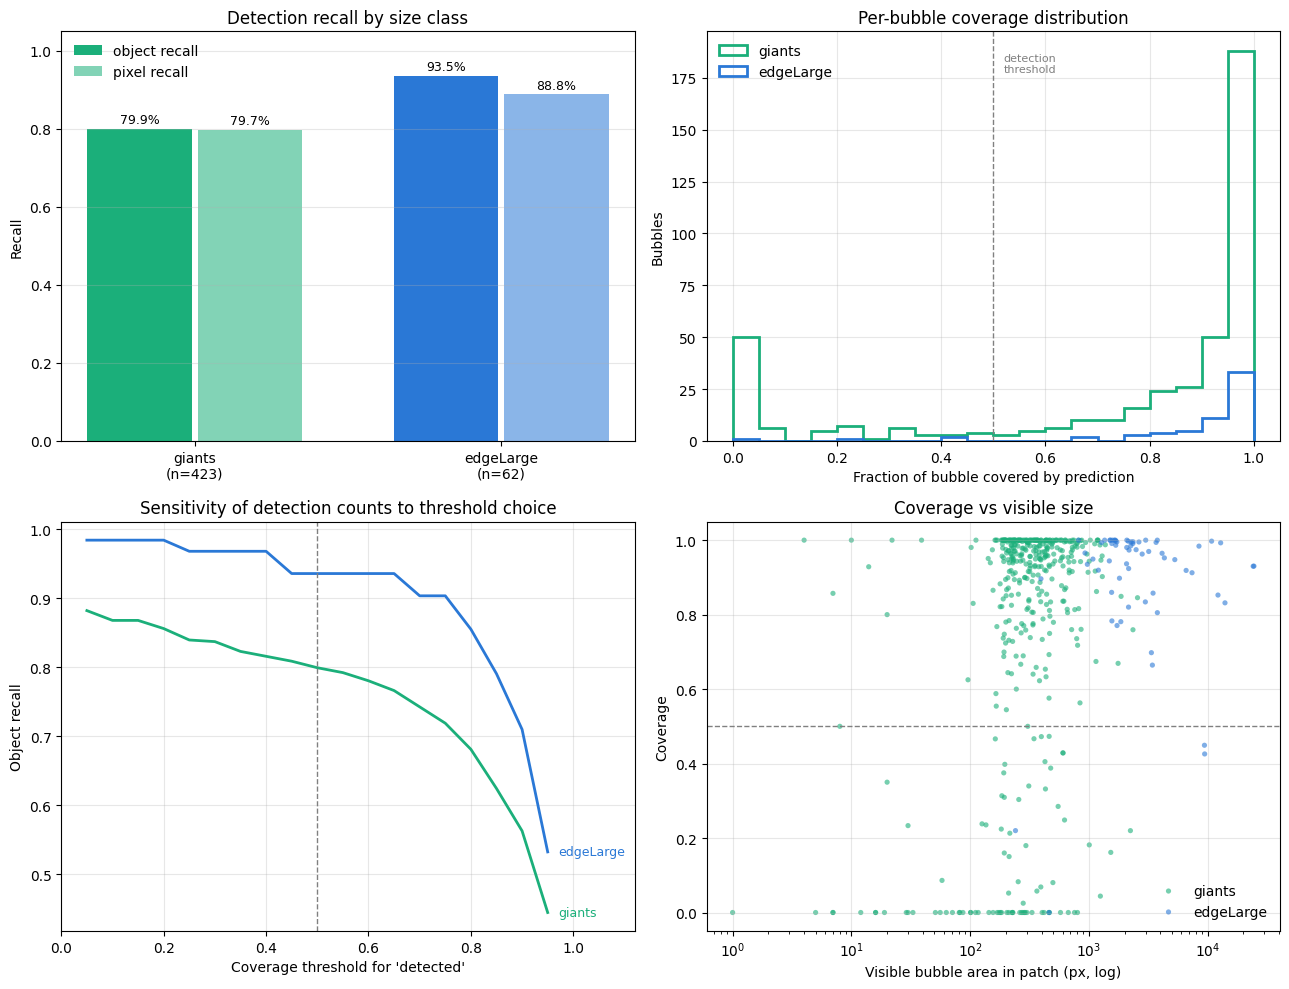

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- panel 1: object vs pixel recall per class
ax = axes[0, 0]

xs = np.arange(len(CURRICULUM_STAGES[ACTIVE_STAGE]))

for k, (metric, shade) in enumerate([("object_recall", 1.0), ("pixel_recall", 0.55)]):
    vals = [summary.loc[c, metric] for c in CURRICULUM_STAGES[ACTIVE_STAGE]]
    bars = ax.bar(xs + (k - 0.5) * 0.36, vals, width=0.34,
                  color=[CLASS_COLORS[c] for c in CURRICULUM_STAGES[ACTIVE_STAGE]],
                  alpha=shade, label=metric.replace("_", " "))
    for x, v in zip(xs + (k - 0.5) * 0.36, vals):
        ax.text(x, v + 0.015, f"{v:.1%}", ha="center", fontsize=9)
ax.set_xticks(xs)
ax.set_xticklabels([f"{c}\n(n={int(summary.loc[c, 'n_bubbles'])})" for c in CURRICULUM_STAGES[ACTIVE_STAGE]])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Recall")
ax.set_title("Detection recall by size class")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

# --- panel 2: per-bubble coverage distribution
ax = axes[0, 1]
for c in CURRICULUM_STAGES[ACTIVE_STAGE]:
    ax.hist(bubbles.loc[bubbles.size_class == c, "coverage"], bins=20,
            range=(0, 1), histtype="step", linewidth=2,
            color=CLASS_COLORS[c], label=c)
ax.axvline(COVERAGE_THRESHOLD, color="gray", linestyle="--", linewidth=1)
ax.text(COVERAGE_THRESHOLD + 0.02, ax.get_ylim()[1] * 0.9,
        "detection\nthreshold", fontsize=8, color="gray")
ax.set_xlabel("Fraction of bubble covered by prediction")
ax.set_ylabel("Bubbles")
ax.set_title("Per-bubble coverage distribution")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

# --- panel 3: object recall vs detection threshold
ax = axes[1, 0]
sweep = np.arange(0.05, 0.96, 0.05)
for c in CURRICULUM_STAGES[ACTIVE_STAGE]:
    cov = bubbles.loc[bubbles.size_class == c, "coverage"]
    recall = [(cov >= t).mean() for t in sweep]
    ax.plot(sweep, recall, color=CLASS_COLORS[c], linewidth=2)
    ax.text(sweep[-1] + 0.02, recall[-1], c, color=CLASS_COLORS[c],
            fontsize=9, va="center")
ax.axvline(COVERAGE_THRESHOLD, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Coverage threshold for 'detected'")
ax.set_ylabel("Object recall")
ax.set_title("Sensitivity of detection counts to threshold choice")
ax.set_xlim(0, 1.12)
ax.grid(alpha=0.3)

# --- panel 4: coverage vs visible size (diagnoses sliver artifact)
ax = axes[1, 1]
for c in CURRICULUM_STAGES[ACTIVE_STAGE]:
    g = bubbles[bubbles.size_class == c]
    ax.scatter(g.visible_px, g.coverage, s=14, alpha=0.6,
               color=CLASS_COLORS[c], label=c, edgecolors="none")
ax.axhline(COVERAGE_THRESHOLD, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Visible bubble area in patch (px, log)")
ax.set_ylabel("Coverage")
ax.set_title("Coverage vs visible size")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()

output_summary = os.path.join(PLOTS_PATH, "perClassEvalSummary.png")
plt.savefig(output_summary, dpi=300, bbox_inches="tight")
plt.show()

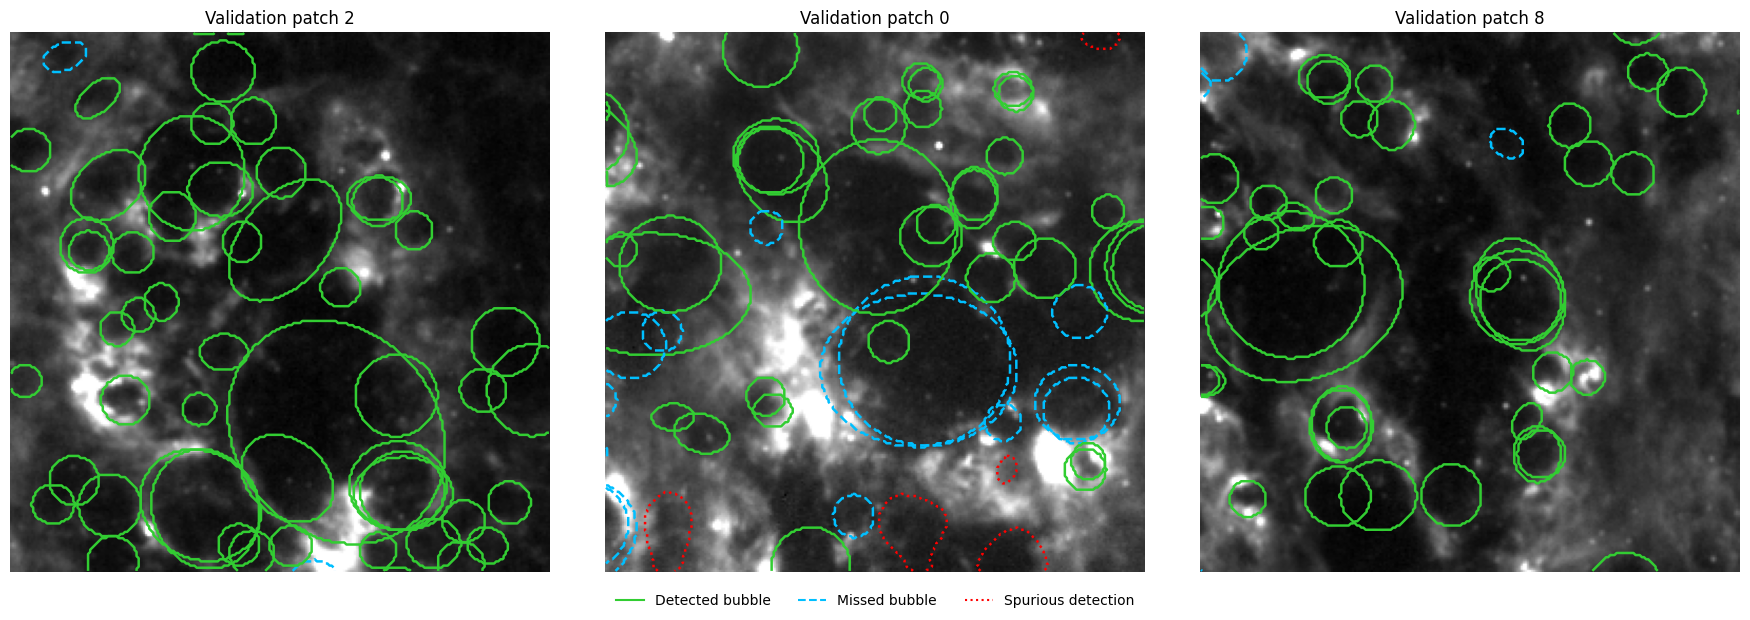

In [79]:
# detection maps: bubble outlines colored by outcome, spurious blobs contoured
detected_by_id = dict(zip(bubbles.global_id, bubbles.detected))
patch_counts = pd.Series([r["patch"] for r in records]).value_counts()
show_patches = patch_counts.index[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, p in zip(axes, show_patches):
    ax.imshow(np.squeeze(X_val_ref[p]), cmap="gray")

    for rec in (r for r in records if r["patch"] == p):
        m = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=float)
        m[rec["rr"], rec["cc"]] = 1
        if detected_by_id[rec["global_id"]]:
            ax.contour(m, levels=[0.5], colors="limegreen",
                       linestyles="solid", linewidths=1.8)
        else:
            ax.contour(m, levels=[0.5], colors="deepskyblue",
                       linestyles="dashed", linewidths=1.8)

    labels_arr, n = ndimage.label(pred_bin[p])
    for i in range(1, n + 1):
        blob = labels_arr == i
        if blob.sum() >= MIN_BLOB_PX and not (blob & union[p]).any():
            ax.contour(blob.astype(float), levels=[0.5], colors="red",
                       linestyles="dotted", linewidths=1.8)

    ax.set_title(f"Validation patch {p}")
    ax.axis("off")

legend_items = [
    Line2D([], [], color="limegreen", linestyle="solid", label="Detected bubble"),
    Line2D([], [], color="deepskyblue", linestyle="dashed", label="Missed bubble"),
    Line2D([], [], color="red", linestyle="dotted", label="Spurious detection"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])

output_patches = os.path.join(FIGURE_DIR, "perClassEvalPatches.png")

plt.savefig(output_patches, dpi=300, bbox_inches="tight")
plt.show()

In [59]:
mosaic = np.load(IMAGE_PATH)

H, W = 1177, 2380
assert mosaic.shape == (H, W), f"shape {mosaic.shape} != patch grid {(H, W)} - overlays would misalign"

val_mask = np.zeros((H, W), dtype=bool)
for _, row in val_meta.iterrows():
    ys, xs = int(row.y_start), int(row.x_start)
    val_mask[ys:ys + PATCH_SIZE, xs:xs + PATCH_SIZE] = True

# (bubble outcome masks and spurious blobs: identical to before)
detected_by_id = dict(zip(bubbles.global_id, bubbles.detected))
df_by_id = df.set_index("GLOBAL_ID")
detected_full = np.zeros((H, W), dtype=float)
missed_full = np.zeros((H, W), dtype=float)
for gid in bubbles.global_id:
    bub = df_by_id.loc[gid]
    rr, cc = ellipse(
        r=bub.y_pix, c=bub.x_pix,
        r_radius=bub.b_pix, c_radius=bub.a_pix,
        rotation=np.deg2rad(bub.PA_DEG), shape=(H, W),
    )
    (detected_full if detected_by_id[gid] else missed_full)[rr, cc] = 1

spurious_full = np.zeros((H, W), dtype=float)
for p, row in val_meta.iterrows():
    ys, xs = int(row.y_start), int(row.x_start)
    labels_arr, n = ndimage.label(pred_bin[p])
    for i in range(1, n + 1):
        blob = labels_arr == i
        if blob.sum() >= MIN_BLOB_PX and not (blob & union[p]).any():
            spurious_full[ys:ys + PATCH_SIZE, xs:xs + PATCH_SIZE] += blob


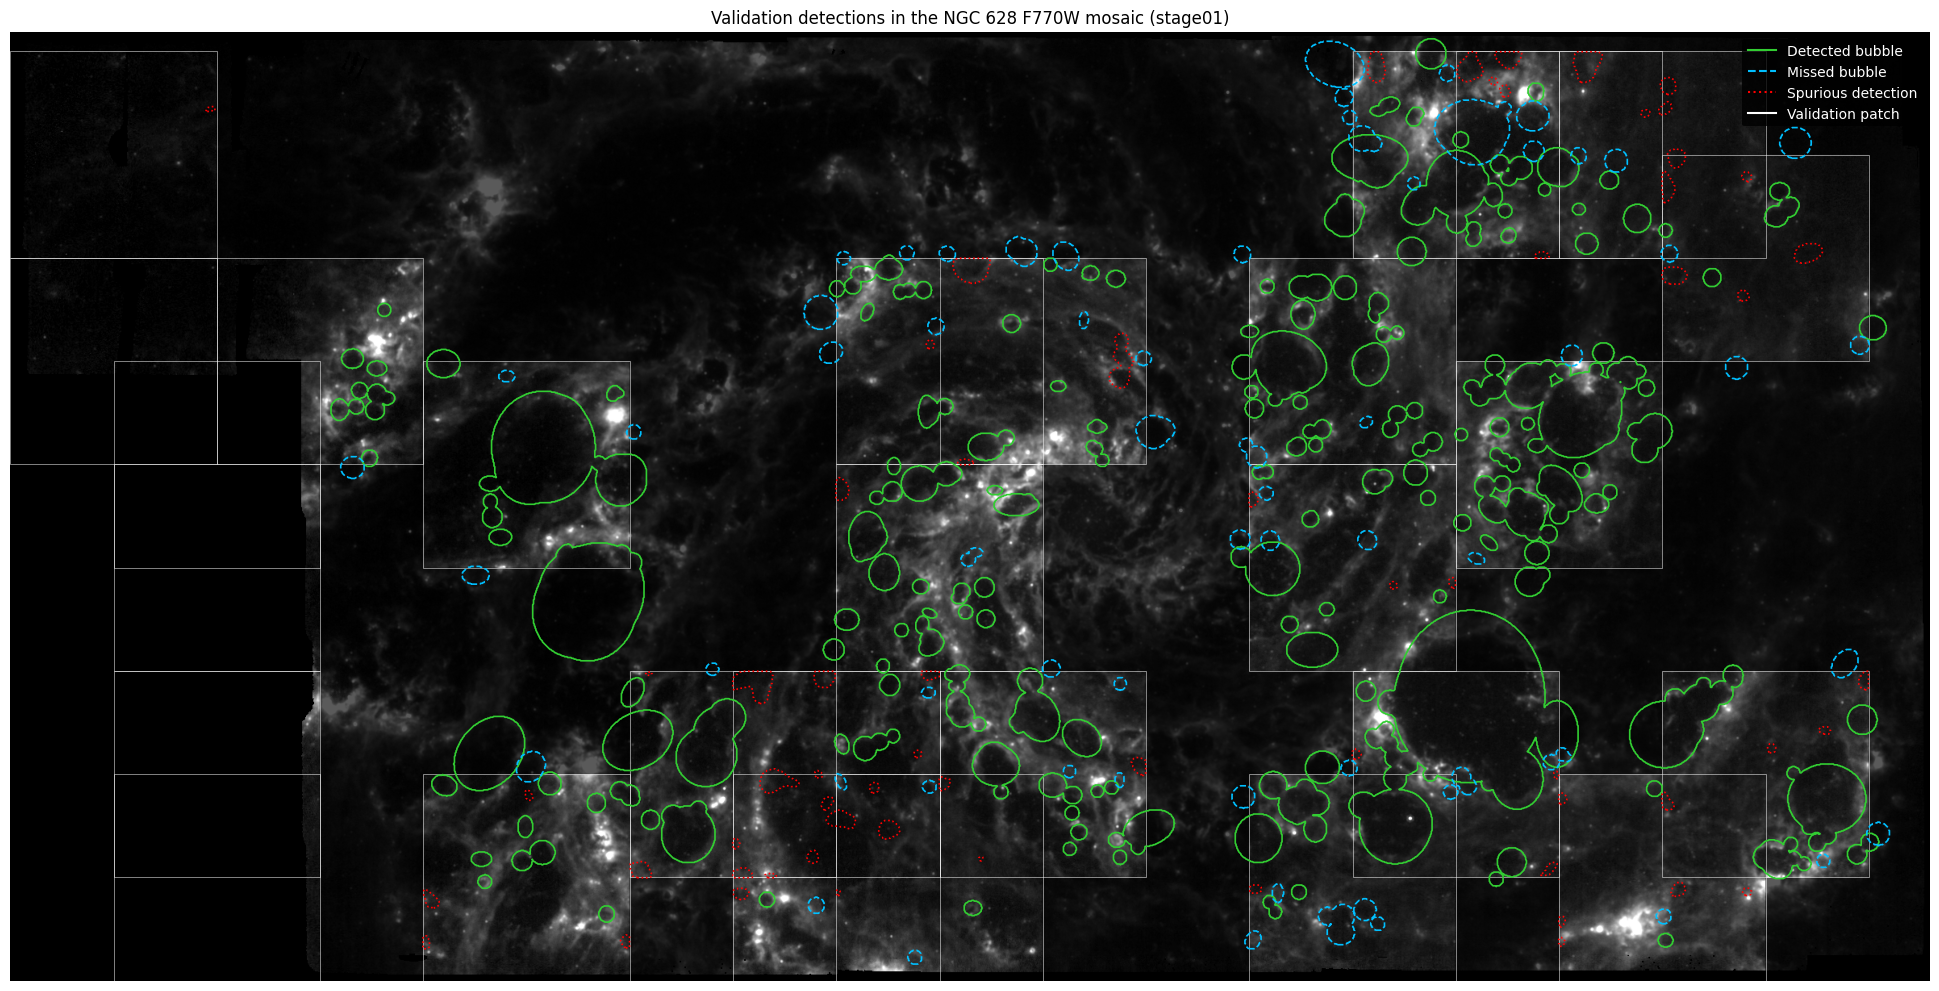

In [62]:

fig, ax = plt.subplots(figsize=(20, 10))

# asinh stretch with percentile limits; NaN (mosaic edges) rendered black
vmin, vmax = np.nanpercentile(mosaic, [0.5, 99.8])
cmap = plt.cm.gray.copy()
cmap.set_bad("black")
ax.imshow(mosaic, cmap=cmap, origin="lower",
          norm=AsinhNorm(linear_width=max(vmax * 0.02, 1e-6), vmin=vmin, vmax=vmax))

# dim outside validation regions via overlay (stretch-independent)
dim = np.zeros((H, W, 4))
dim[..., 3] = np.where(val_mask, 0.0, 0.65)
ax.imshow(dim, origin="lower")

ax.contour(detected_full, levels=[0.5], colors="limegreen",
           linestyles="solid", linewidths=1.2)
ax.contour(missed_full, levels=[0.5], colors="deepskyblue",
           linestyles="dashed", linewidths=1.2)
ax.contour((spurious_full > 0).astype(float), levels=[0.5], colors="red",
           linestyles="dotted", linewidths=1.2)

for _, row in val_meta.iterrows():
    ax.add_patch(Rectangle((row.x_start, row.y_start), PATCH_SIZE, PATCH_SIZE,
                           fill=False, edgecolor="white", linewidth=0.6, alpha=0.6))

legend_items = [
    Line2D([], [], color="limegreen", linestyle="solid", label="Detected bubble"),
    Line2D([], [], color="deepskyblue", linestyle="dashed", label="Missed bubble"),
    Line2D([], [], color="red", linestyle="dotted", label="Spurious detection"),
    Line2D([], [], color="white", linestyle="solid", label="Validation patch"),
]
ax.legend(handles=legend_items, loc="upper right", frameon=True,
          facecolor="black", labelcolor="white", edgecolor="none")
ax.set_title("Validation detections in the NGC 628 F770W mosaic (stage01)")
ax.axis("off")

plt.tight_layout()

# saving class mosiac png file

output_mosaic = os.path.join(FIGURE_DIR, "perClassEvalMosaic.png")
# output_mosaic = os.path.join(FIGURE_DIR, "perClassEvalMosaic.pdf")

plt.savefig(output_mosaic, dpi=300, bbox_inches="tight")
plt.show()